<a href="https://colab.research.google.com/github/raveesharanamukage/Intelligent-Systems-n-ML/blob/main/Dataset_preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import necessary Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime

## Exploratary Data Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#with open('/content/drive/MyDrive/Datasets/hotel/Hotel_Revenue_Data .csv','r') as f:
  #data=f.read()
 # f.close()

In [ ]:
column_names=['Date','MealPeriod','RevenueCentreName','CheckTotal']
df=pd.read_csv('/content/drive/MyDrive/Datasets/hotel/transaction_summary.csv',header=None,names=column_names,parse_dates=['Date'])
print(df.head())
print(df.info()) #Consice summary of the DataFrame
print(df.describe())

         Date         MealPeriod RevenueCentreName  CheckTotal
0        Date  RevenueCentreName        CheckTotal         NaN
1  2023-01-01    RevenueCenter_1            7133.9         NaN
2  2023-01-02    RevenueCenter_1            5273.0         NaN
3  2023-01-03    RevenueCenter_1            4864.3         NaN
4  2023-01-04    RevenueCenter_1            6278.0         NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487 entries, 0 to 486
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               487 non-null    object 
 1   MealPeriod         487 non-null    object 
 2   RevenueCentreName  487 non-null    object 
 3   CheckTotal         0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 15.3+ KB
None
       CheckTotal
count         0.0
mean          NaN
std           NaN
min           NaN
25%           NaN
50%           NaN
75%           NaN
max           NaN


/tmp/ipython-input-23-4081440958.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df=pd.read_csv('/content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_1.csv',header=None,names=column_names,parse_dates=['Date'])


In [ ]:
df.head()

,Date,MealPeriod,RevenueCentreName,CheckTotal
0,2023-01-01,BreakFast,RevenueCenter_1,1499.4
1,2023-01-01,BreakFast,RevenueCenter_2,35.0
2,2023-01-01,BreakFast,RevenueCenter_4,0.0
3,2023-01-01,BreakFast,RevenueCenter_5,21807.0
4,2023-01-01,BreakFast,RevenueCenter_6,93.0


## Introduction
### About the Project
+ This project is a hotel revenue forecasting using ML with gaining valuable insights to the client.
+ First it has 9 Revenue Centres
+ Given the data with date and time of the day as MealPeriod
+ First Task is to Forecast Revenue for two months for each Hotel Per MealPeriod


In [ ]:
df.index.dtype
stamp = df.index[5]
df.loc[stamp]

,5
Date,2023-01-01 00:00:00
MealPeriod,Lunch
RevenueCentreName,RevenueCenter_1
CheckTotal,1260.0


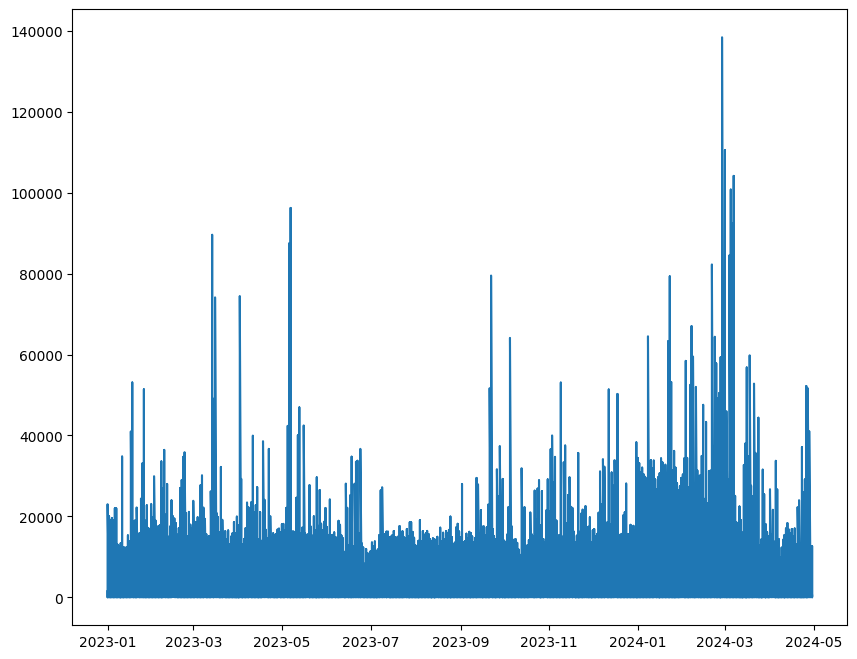

In [ ]:
#Visualize the revenue without considering meal period,revenue centre
plt.figure(figsize=(10,8))
plt.plot(df['Date'],df['CheckTotal'])
plt.show()

#### Task Combinations
Assign a unique Id to each revenue centre and meal period combination

In [ ]:
revenue_centres=df['RevenueCentreName'].unique()
meal_periods=df['MealPeriod'].unique()
num_tasks=len(revenue_centres)*len(meal_periods)

all_combin=[(mp,rc) for mp in meal_periods for rc in revenue_centres]
print(all_combin)

#Create a mapping of task IDs
task_mapping={mp+'_' + rc:i for i,(mp,rc) in enumerate(all_combin)}
task_mapping

[('BreakFast', 'RevenueCenter_1'), ('BreakFast', 'RevenueCenter_2'), ('BreakFast', 'RevenueCenter_4'), ('BreakFast', 'RevenueCenter_5'), ('BreakFast', 'RevenueCenter_6'), ('BreakFast', 'RevenueCenter_3'), ('BreakFast', 'RevenueCenter_9'), ('BreakFast', 'RevenueCenter_8'), ('BreakFast', 'RevenueCenter_7'), ('Lunch', 'RevenueCenter_1'), ('Lunch', 'RevenueCenter_2'), ('Lunch', 'RevenueCenter_4'), ('Lunch', 'RevenueCenter_5'), ('Lunch', 'RevenueCenter_6'), ('Lunch', 'RevenueCenter_3'), ('Lunch', 'RevenueCenter_9'), ('Lunch', 'RevenueCenter_8'), ('Lunch', 'RevenueCenter_7'), ('Dinner', 'RevenueCenter_1'), ('Dinner', 'RevenueCenter_2'), ('Dinner', 'RevenueCenter_4'), ('Dinner', 'RevenueCenter_5'), ('Dinner', 'RevenueCenter_6'), ('Dinner', 'RevenueCenter_3'), ('Dinner', 'RevenueCenter_9'), ('Dinner', 'RevenueCenter_8'), ('Dinner', 'RevenueCenter_7')]


{'BreakFast_RevenueCenter_1': 0,
 'BreakFast_RevenueCenter_2': 1,
 'BreakFast_RevenueCenter_4': 2,
 'BreakFast_RevenueCenter_5': 3,
 'BreakFast_RevenueCenter_6': 4,
 'BreakFast_RevenueCenter_3': 5,
 'BreakFast_RevenueCenter_9': 6,
 'BreakFast_RevenueCenter_8': 7,
 'BreakFast_RevenueCenter_7': 8,
 'Lunch_RevenueCenter_1': 9,
 'Lunch_RevenueCenter_2': 10,
 'Lunch_RevenueCenter_4': 11,
 'Lunch_RevenueCenter_5': 12,
 'Lunch_RevenueCenter_6': 13,
 'Lunch_RevenueCenter_3': 14,
 'Lunch_RevenueCenter_9': 15,
 'Lunch_RevenueCenter_8': 16,
 'Lunch_RevenueCenter_7': 17,
 'Dinner_RevenueCenter_1': 18,
 'Dinner_RevenueCenter_2': 19,
 'Dinner_RevenueCenter_4': 20,
 'Dinner_RevenueCenter_5': 21,
 'Dinner_RevenueCenter_6': 22,
 'Dinner_RevenueCenter_3': 23,
 'Dinner_RevenueCenter_9': 24,
 'Dinner_RevenueCenter_8': 25,
 'Dinner_RevenueCenter_7': 26}

Preprocess Data into sequences
* Prepare X(feature matrix) and y(target array)
* Adding Sliding window approach to add past data to predict the present value(values if forecast horizon>1)
* Create a sequence for all 27 datasets with the sliding window
* Index all the data points to for the modeule to identify the MealPeriod and RevenueCentre.
* Standardized the data to reduce the variance and enhance minimizing loss for te model.
* Save the Scalars for each combination to transform to original scale and forecast.

In [ ]:
print(df.groupby(['MealPeriod','RevenueCentreName']).size())

MealPeriod  RevenueCentreName
BreakFast   RevenueCenter_1      485
            RevenueCenter_2      456
            RevenueCenter_3      400
            RevenueCenter_4      314
            RevenueCenter_5      486
            RevenueCenter_6      295
            RevenueCenter_7      284
            RevenueCenter_8       42
            RevenueCenter_9      342
Dinner      RevenueCenter_1      486
            RevenueCenter_2      465
            RevenueCenter_3      486
            RevenueCenter_4      472
            RevenueCenter_5      486
            RevenueCenter_6      469
            RevenueCenter_7      385
            RevenueCenter_8      291
            RevenueCenter_9      179
Lunch       RevenueCenter_1      482
            RevenueCenter_2      465
            RevenueCenter_3      486
            RevenueCenter_4      181
            RevenueCenter_5      479
            RevenueCenter_6      430
            RevenueCenter_7      265
            RevenueCenter_8      220
        

In [ ]:
print(df.groupby(['RevenueCentreName']).size())

RevenueCentreName
RevenueCenter_1    1453
RevenueCenter_2    1386
RevenueCenter_3    1372
RevenueCenter_4     967
RevenueCenter_5    1451
RevenueCenter_6    1194
RevenueCenter_7     934
RevenueCenter_8     553
RevenueCenter_9     880
dtype: int64


In [ ]:
import pandas as pd



# Group by Date and RevenueCenterName, then sum the CheckTotal
revenue_by_date_center = df.groupby(['Date','RevenueCentreName'])['CheckTotal'].sum().reset_index()

# Print the total revenue for each revenue center per date
print("Total Revenue per Revenue Center per Date:")
print(revenue_by_date_center)



Total Revenue per Revenue Center per Date:
           Date RevenueCentreName  CheckTotal
0    2023-01-01   RevenueCenter_1      7133.9
1    2023-01-01   RevenueCenter_2       472.0
2    2023-01-01   RevenueCenter_3     10204.9
3    2023-01-01   RevenueCenter_4         0.0
4    2023-01-01   RevenueCenter_5     26617.0
...         ...               ...         ...
4189 2024-04-30   RevenueCenter_5     15515.0
4190 2024-04-30   RevenueCenter_6       474.0
4191 2024-04-30   RevenueCenter_7        97.0
4192 2024-04-30   RevenueCenter_8     12640.0
4193 2024-04-30   RevenueCenter_9       665.0

[4194 rows x 3 columns]


In [ ]:
print(revenue_by_date_center.groupby(['RevenueCentreName']).size())

RevenueCentreName
RevenueCenter_1    486
RevenueCenter_2    483
RevenueCenter_3    486
RevenueCenter_4    478
RevenueCenter_5    486
RevenueCenter_6    476
RevenueCenter_7    456
RevenueCenter_8    412
RevenueCenter_9    431
dtype: int64


In [ ]:
# Save the results to CSV files on your drive
revenue_by_date_center.to_csv('revenue_by_date_center.csv', index=False)


In [ ]:
# Save a separate CSV file for each revenue center
unique_centers = revenue_by_date_center['RevenueCentreName'].unique()
for center in unique_centers:
    # Filter data for the current revenue center
    center_data = revenue_by_date_center[revenue_by_date_center['RevenueCentreName'] == center]
    # Save to a file named after the revenue center
    file_name_path = f"/content/drive/MyDrive/Datasets/hotel/Total RC datasets/{center}.csv"
    center_data.to_csv(file_name_path, index=False)
    print(f"Saved data for {center} to {file_name_path}")

Saved data for RevenueCenter_1 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_1.csv
Saved data for RevenueCenter_2 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_2.csv
Saved data for RevenueCenter_3 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_3.csv
Saved data for RevenueCenter_4 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_4.csv
Saved data for RevenueCenter_5 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_5.csv
Saved data for RevenueCenter_6 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_6.csv
Saved data for RevenueCenter_8 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_8.csv
Saved data for RevenueCenter_9 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_9.csv
Saved data for RevenueCenter_7 to /content/drive/MyDrive/Datasets/hotel/Total RC datasets/RevenueCenter_7.csv
